# Digital Twin for HAADF and EDS



In [1]:
import sys
from pathlib import Path
import time
import json

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import subprocess
import numpy as np
import matplotlib.pyplot as plt
from asyncroscopy.ThermoHaadfEdsTwin import ThermoHaadfEdsTwin
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.detectors.EDS import EDS
from asyncroscopy.hardware.SCAN import SCAN

import tango

## 1. Connect to devices

In [2]:
# ── Kill anything already on port 11000 ──────────────────────────────────────
print("Clearing old processes...")
subprocess.run("kill -9 $(lsof -t -i:11000) 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'STAGE stage' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'SCAN scan' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true", shell=True)
time.sleep(2)

Clearing old processes...


In [3]:
devices_info = [
    {
        "class": SCAN,
        "devices": [
            {
                "name": "test/detector/scan",
                "properties": {},
            }
        ],
    },

    {
        "class": EDS,
        "devices": [
            {
                "name": "test/detector/eds",
                "properties": {},
            }
        ],
    },
    
    {
        "class": ThermoHaadfEdsTwin,
        "devices": [
            {
                "name": "test/detector/microscope",
                "properties": {
                    "eds_device_address": "test/detector/eds",
                    "scan_device_address": "test/detector/scan",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

scan_proxy = tango.DeviceProxy("test/detector/scan")
mic_proxy = tango.DeviceProxy("test/detector/microscope")
eds_proxy = tango.DeviceProxy("test/detector/eds")

print(f"Device state: {mic_proxy.state()}")


2026-03-25T11:23:18,741593-0400 INFO (SCAN.py:63) test/detector/scan SCAN device initialised
2026-03-25T11:23:18,742510-0400 INFO (EDS.py:49) test/detector/eds EDS device initialised
{'haadf': None, 'AdvancedAcquistion': None, 'eds': 'test/detector/eds', 'stage': None, 'scan': 'test/detector/scan'}
2026-03-25T11:23:18,744920-0400 INFO (ThermoHaadfEdsTwin.py:94) test/detector/microscope Skipping haadf: no address configured
2026-03-25T11:23:18,744941-0400 INFO (ThermoHaadfEdsTwin.py:94) test/detector/microscope Skipping AdvancedAcquistion: no address configured
2026-03-25T11:23:18,745148-0400 INFO (ThermoHaadfEdsTwin.py:98) test/detector/microscope Connected to detector proxy: eds @ test/detector/eds
2026-03-25T11:23:18,745172-0400 INFO (ThermoHaadfEdsTwin.py:94) test/detector/microscope Skipping stage: no address configured
2026-03-25T11:23:18,745279-0400 INFO (ThermoHaadfEdsTwin.py:98) test/detector/microscope Connected to detector proxy: scan @ test/detector/scan
Ready to accept requ

## Acquire Simulated Image

Acquire an image from the HAADF detector and visualize it.

Placed 40 particles
Acceleration voltage 200.0kV  => wavelength 2.51pm
0.03
Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'float32', 'dwell_time': 1e-06, 'timestamp': 1774452214.804205}


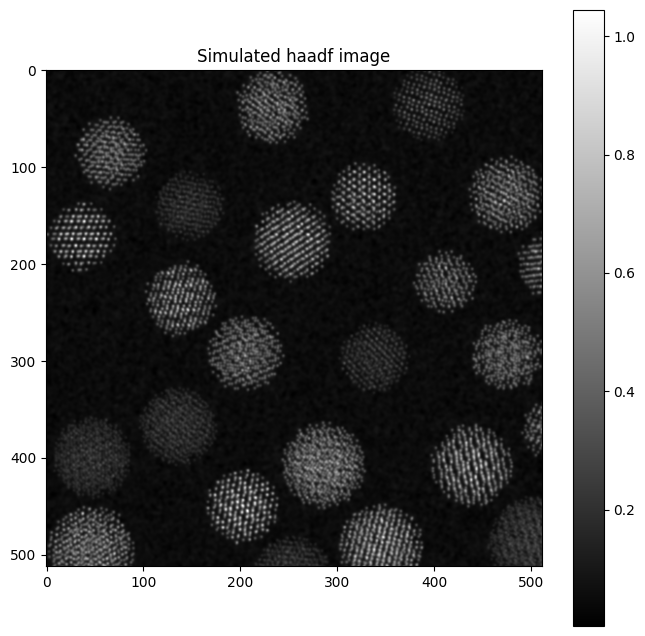

In [4]:
json_meta, raw_bytes = mic_proxy.get_scanned_image()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()

In [7]:
mic_proxy.place_beam([0.56, 0.65])

## Query beam

In [8]:
beam_pos = mic_proxy.beam_pos

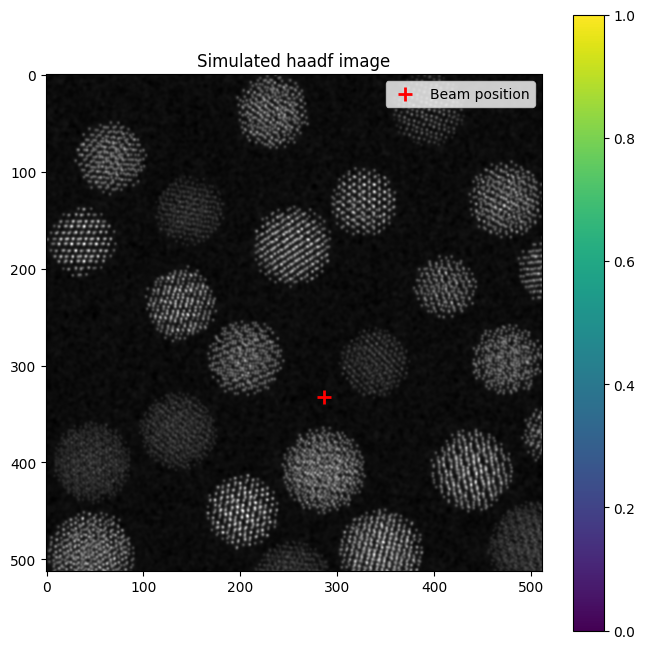

In [9]:
# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = mic_proxy.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {meta['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

## EDS

In [10]:
json_meta, raw_bytes = mic_proxy.get_spectrum('eds')
metadata  = dict(json.loads(json_meta))
spectrum = dict(json.loads(raw_bytes))
spectrum

{'Au': 0.07639582329550186,
 'Fe': 0.04427947540553527,
 'Pt': 0.010657288789959363}